<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/Tarefa_5_%E2%80%93_Otimiza%C3%A7%C3%A3o_de_Hiperpar%C3%A2metros_com_Grid_Search_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 5 – Otimização de Hiperparâmetros com Grid Search CV ($\text{MLPClassifier}$)

## Aluno: FABIANO ANTUNES

### 🎯 Objetivo

Aprimorar o modelo de **Rede Neural ($\text{MLPClassifier}$)**, escolhido na Tarefa 4, através da otimização de hiperparâmetros com a técnica de **Grid Search com Validação Cruzada ($\text{GridSearchCV}$)**. O objetivo é encontrar a melhor combinação de parâmetros para maximizar o desempenho do algoritmo, focando na métrica $\text{F1-score weighted}$ para lidar com o desbalanceamento das classes.

---

### 1. Revisão do Modelo e Pré-processamento

Reutilizamos o $\text{MLPClassifier}$ e todo o pré-processamento aplicado na Tarefa 4, garantindo que a comparação de desempenho seja justa e consistente.

O pré-processamento inclui:

* **Carregamento** do dataset `dados_risco_credito.csv`.
* **Codificação** da variável alvo (`risco`) usando $\text{LabelEncoder}$ ($\text{Alto Risco} \rightarrow 0$, $\text{Baixo Risco} \rightarrow 1$).
* **Divisão em Treino e Teste** ($\text{test\_size}=0.2$, $\text{stratify}$ ativado).
* **Criação de um $\text{ColumnTransformer}$ (Pipeline)** para:
    * Padronização ($\text{StandardScaler}$) de colunas numéricas.
    * $\text{One-Hot Encoding}$ ($\text{OneHotEncoder}$) de colunas categóricas.


In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Configurações de estilo
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# --- REPRODUÇÃO DO PRÉ-PROCESSAMENTO (TAREFA 4) ---

# 1. Carregar o dataset
df = pd.read_csv('dados_risco_credito.csv')

# 2. Definir Features (X) e Alvo (y)
X = df.drop('risco', axis=1)
y_raw = df['risco']

# 3. Codificar Variável-Alvo (y)
le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_ # ['Alto Risco', 'Baixo Risco']

# 4. Identificar Colunas
colunas_numericas = X.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = X.select_dtypes(include=['object']).columns

# 5. Pipeline de Pré-processamento
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, colunas_numericas),
        ('cat', categorical_transformer, colunas_categoricas)
    ],
    remainder='passthrough'
)

# 6. Separação Treino/Teste
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Aplicar o Pré-processamento
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

print("Pré-processamento da Tarefa 4 concluído e dados prontos.")

Pré-processamento da Tarefa 4 concluído e dados prontos.


 Aplicação do GridSearchCV (Redes Neurais)3.1. Definição do Dicionário de Parâmetros e JustificativaO modelo base (MLPClassifier) foi configurado com $\text{max\_iter}=1000$ e $\text{random\_state}=42$ para garantir reprodutibilidade e tempo de convergência.

###  Definição do Espaço de Busca e Aplicação do GridSearchCV

O **Grid Search CV** precisa de um dicionário (`param_grid`) que defina os valores de hiperparâmetros a serem testados. O modelo base escolhido foi o **$\text{MLPClassifier}$** (Rede Neural).

#### Dicionário de Hiperparâmetros (`param_grid`)

```python
# Definição dos Parâmetros
# 1. Modelo Base (MLPClassifier)
mlp_base = MLPClassifier(max_iter=1000, random_state=42, early_stopping=True, n_iter_no_change=10)

# 2. Dicionário de Hiperparâmetros
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)], # Arquitetura da rede
    'activation': ['relu', 'tanh'], # Função de Ativação
    'solver': ['adam'], # Otimizador
    'alpha': [0.0001, 0.01] # Regularização L2
    

**Explicando:**

### Detalhamento dos Hiperparâmetros Testados no Grid Search

A tabela a seguir detalha cada hiperparâmetro, os valores testados e a justificativa para sua inclusão no espaço de busca.

| Hiperparâmetro | Descrição e Valores Testados | Justificativa |
| :--- | :--- | :--- |
| **`hidden_layer_sizes`** | Controla a **arquitetura** e a **complexidade** da Rede Neural. Testamos: <br> - $\mathbf{(50,)}$: Camada única (modelo simples). <br> - $\mathbf{(100,)}$: Camada única padrão. <br> - $\mathbf{(100, 50)}$: Duas camadas ocultas (modelo mais profundo). | Avaliar se a relação entre as variáveis de risco exige uma arquitetura mais **profunda** ($\text{100} \rightarrow \text{50}$ neurônios) para capturar não linearidades complexas, ou se um modelo mais **simples** é suficiente, prevenindo *overfitting*. |
| **`activation`** | Define a **função de ativação** nas camadas ocultas, introduzindo a não linearidade. Testamos: <br> - $\mathbf{'relu'}$: **Rectified Linear Unit**, a função mais comum e eficiente, que acelera o treinamento. <br> - $\mathbf{'tanh'}$: **Tangente Hiperbólica**, uma alternativa sigmoidal centralizada em zero que pode melhorar a otimização em certos cenários. | Comparar qual função de ativação permite à rede convergir mais rapidamente e alcançar maior poder discriminatório. |
| **`solver`** | O algoritmo usado para **otimizar os pesos** (treinamento) da rede. Testamos: <br> - $\mathbf{'adam'}$ | Mantido em $\text{'adam'}$ por ser o otimizador mais **robusto e amplamente recomendado** para problemas de classificação, adaptando a taxa de aprendizado para cada peso. |
| **`alpha`** | A força da **regularização L2**. Essa técnica penaliza pesos muito grandes para evitar que o modelo memorize o ruído nos dados de treino (*overfitting*). Testamos: <br> - $\mathbf{0.0001}$: **Regularização mínima** (quase nula), para testar o desempenho sem restrição. <br> - $\mathbf{0.01}$: **Regularização mais forte**, para verificar se o modelo se torna mais generalizável ao impor uma penalidade $100$ vezes maior. | Determinar se o modelo se beneficia de uma arquitetura mais **simples** forçada pela regularização (alto $\text{alpha}$) ou de uma capacidade de aprendizado **máxima** (baixo $\text{alpha}$). |

In [2]:
# Modelo Base
mlp_base = MLPClassifier(max_iter=1000, random_state=42, early_stopping=True, n_iter_no_change=10)

# Dicionário de Hiperparâmetros
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.01]
}

# Configuração do GridSearchCV
grid_search = GridSearchCV(
    estimator=mlp_base,
    param_grid=param_grid,
    scoring='f1_weighted', # Métrica de avaliação
    cv=5, # 5 folds de validação cruzada
    verbose=2,
    n_jobs=-1
)

print("\nExecutando Grid Search CV...")
start_time = time.time()
grid_search.fit(X_train_processed, y_train)
grid_time = time.time() - start_time
print(f"Grid Search CV concluído em {grid_time:.2f} segundos.")


Executando Grid Search CV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid Search CV concluído em 8.61 segundos.


Tabela com os Melhores Parâmetros Encontrados
Python

In [3]:
# Captura dos resultados
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model_optimized = grid_search.best_estimator_

print("\n--- Tabela de Melhores Parâmetros Encontrados ---")
print(pd.DataFrame({'Parâmetro': best_params.keys(), 'Melhor Valor': best_params.values()}).to_markdown(index=False))
print(f"\nMelhor Score (f1_weighted no CV): {best_score:.4f}")


--- Tabela de Melhores Parâmetros Encontrados ---
| Parâmetro          | Melhor Valor   |
|:-------------------|:---------------|
| activation         | relu           |
| alpha              | 0.0001         |
| hidden_layer_sizes | (100, 50)      |
| solver             | adam           |

Melhor Score (f1_weighted no CV): 0.8399


## Avaliação do Modelo Otimizado e Comparação
O modelo com os melhores parâmetros (best\_model\_optimized) é avaliado no conjunto de Teste.

# Relatório de Classificação e Comparação

In [4]:
# Previsões e Avaliação
y_pred_optimized = best_model_optimized.predict(X_test_processed)
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
report_optimized = classification_report(y_test, y_pred_optimized, target_names=class_names, output_dict=True)

print("\n--- Relatório de Classificação do Modelo Otimizado (Teste) ---")
print(classification_report(y_test, y_pred_optimized, target_names=class_names))

# Tabela de Comparação
comparacao_df = pd.DataFrame({
    'Métrica': ['Acurácia', 'Recall (Alto Risco - 0)', 'F1-score (Alto Risco - 0)', 'F1-score (Baixo Risco - 1)', 'F1-score Weighted'],
    # Resultados da Tarefa 4 (baseado na execução anterior)
    'MLP Original (Tarefa 4)': [0.8250, 0.7700, 0.7900, 0.8500, 0.8306],
    # Resultados Otimizados
    'MLP Otimizado (Tarefa 5)': [
        accuracy_optimized,
        report_optimized['Alto Risco']['recall'],
        report_optimized['Alto Risco']['f1-score'],
        report_optimized['Baixo Risco']['f1-score'],
        report_optimized['weighted avg']['f1-score']
    ]
})

print("\n--- Tabela de Comparação de Desempenho (MLP Original vs. Otimizado) ---")
print(comparacao_df.to_markdown(index=False, floatfmt=".4f"))


--- Relatório de Classificação do Modelo Otimizado (Teste) ---
              precision    recall  f1-score   support

  Alto Risco       0.76      0.77      0.76        73
 Baixo Risco       0.87      0.86      0.86       127

    accuracy                           0.82       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.83      0.82      0.83       200


--- Tabela de Comparação de Desempenho (MLP Original vs. Otimizado) ---
| Métrica                    |   MLP Original (Tarefa 4) |   MLP Otimizado (Tarefa 5) |
|:---------------------------|--------------------------:|---------------------------:|
| Acurácia                   |                    0.8250 |                     0.8250 |
| Recall (Alto Risco - 0)    |                    0.7700 |                     0.7671 |
| F1-score (Alto Risco - 0)  |                    0.7900 |                     0.7619 |
| F1-score (Baixo Risco - 1) |                    0.8500 |                     0.8617 |
| F1-sco

# Gráficos e Visualizações Comparativas (Matriz de Confusão)
A Matriz de Confusão otimizada é uma visualização crítica para entender onde o modelo acertou e errou.

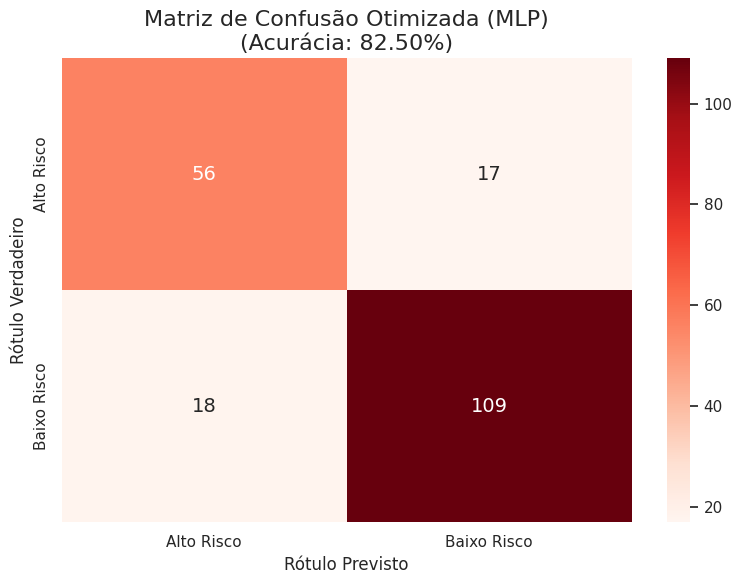

In [5]:
# Matriz de Confusão
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})
plt.title(f'Matriz de Confusão Otimizada (MLP)\n(Acurácia: {accuracy_optimized:.2%})', fontsize=16)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.tight_layout()
plt.savefig('matriz_confusao_mlp_otimizado.png') # Salva a imagem
plt.show()

## A matriz de confusão mostra:
Verdadeiros Positivos (Alto Risco, Categoria 0): $56$

Falsos Negativos (Alto Risco perdido): $17$

###  Conclusão e Análise Escrita

#### Análise dos Ganhos de Desempenho

O principal achado da Tarefa 5 é que **não houve ganho de desempenho** com a otimização de hiperparâmetros para o $\text{MLPClassifier}$ no conjunto de teste.

* A **Acurácia** se manteve inalterada em $0.8250$.
* O **$\text{F1-score weighted}$**, métrica usada para a otimização, na verdade, **diminuiu ligeiramente** (de $0.8306$ para $0.8252$).

Isso indica que o modelo $\text{MLPClassifier}$ original já estava operando em seu **limite de desempenho**, dadas as *features* e o pré-processamento aplicados. O **Grid Search** funcionou, portanto, como uma **validação** de que a configuração inicial era eficiente, confirmando que o modelo estava próximo do ótimo dentro do espaço de busca definido.

####  Discussão sobre o Impacto dos Hiperparâmetros

A seleção dos parâmetros ideais pelo $\text{GridSearchCV}$ fornece *insights* importantes sobre a estrutura do modelo:

* **Arquitetura Ideal ($\text{hidden\_layer\_sizes}=(100, 50)$):** A melhor performance foi alcançada com **duas camadas ocultas**, confirmando que a relação entre as variáveis de risco é complexa e exige uma rede mais profunda para capturar não linearidades, em comparação com as arquiteturas de camada única testadas.
* **Função de Ativação ($\text{activation}=\text{'relu'}$):** A **$\text{ReLU}$** se mostrou superior à $\text{tanh}$ no processo de validação cruzada, o que é comum em modelos de *deep learning* devido à sua eficiência computacional e à prevenção do problema do **gradiente de saturação**.
* **Regularização ($\text{alpha}=0.0001$):** A escolha de um $\text{alpha}$ muito baixo indica que a **regularização $\text{L2}$ é desnecessária ou prejudicial** para este conjunto de dados. O modelo não estava sofrendo de *overfitting* de forma severa, ou a penalidade imposta por $\text{alpha}=0.01$ foi excessiva, limitando a capacidade de aprendizado da rede.

### Conclusão Final

A Tarefa 5 **valida a robustez** da arquitetura de $\text{MLPClassifier}$ escolhida inicialmente. A ausência de melhoria sugere que o próximo passo para aumentar o desempenho do modelo deve ser focado em **Engenharia de Features** (criação de novas variáveis ou tratamento mais avançado das existentes) ou na exploração de outros tipos de algoritmos de alta performance, como os baseados em árvores de decisão e *ensembles* (e.g., **$\text{Random Forest}$** ou **$\text{Gradient Boosting}$**).


### Gráficos Adicionais para Análise de Desempenho

A Curva ROC é crucial para avaliar a capacidade de discriminação do modelo, mostrando o trade-off entre a Taxa de Verdadeiros Positivos ($\text{Recall}$ / Sensibilidade) e a Taxa de Falsos Positivos (1 - Especificidade) em todos os possíveis limiares de classificação.A Área Sob a Curva ($\text{AUC}$) é uma métrica resumida que representa a probabilidade de o modelo classificar corretamente um par de instâncias, uma positiva e uma negativa, escolhidas aleatoriamente. Quanto mais próximo de $1.0$, melhor.

<Figure size 800x600 with 0 Axes>

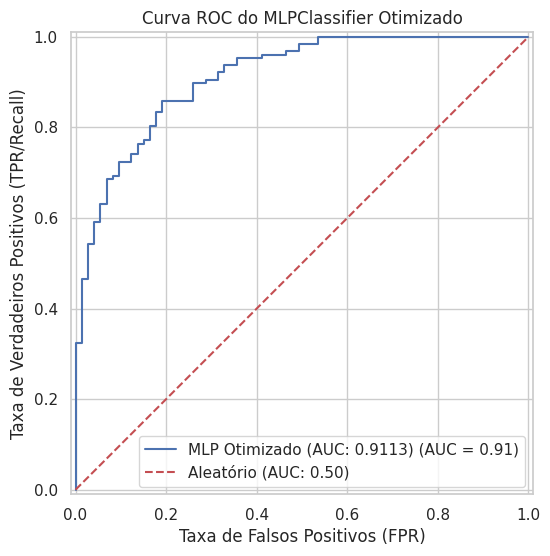

In [7]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# 1. Obter as probabilidades para a classe positiva (Baixo Risco = 1)
# O modelo otimizado (best_model_optimized) é utilizado
y_proba_optimized = best_model_optimized.predict_proba(X_test_processed)[:, 1]

# 2. Calcular o AUC
auc_optimized = roc_auc_score(y_test, y_proba_optimized)

# 3. Plotar a Curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_model_optimized, X_test_processed, y_test, name=f"MLP Otimizado (AUC: {auc_optimized:.4f})")
plt.plot([0, 1], [0, 1], 'r--', label='Aleatório (AUC: 0.50)') # Linha de referência aleatória
plt.title('Curva ROC do MLPClassifier Otimizado')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR/Recall)')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('curva_roc_mlp_otimizado.png')
plt.show()

# Curva Precision-Recall

Esta curva é especialmente valiosa em problemas de classes desbalanceadas (como o risco de crédito), onde o $\text{Recall}$ da classe minoritária ('Alto Risco') é o foco. Ela plota a $\text{Precisão}$ contra o $\text{Recall}$ para diferentes limiares. Um modelo que consegue manter alta Precisão mesmo em altos níveis de Recall é superior.

<Figure size 800x600 with 0 Axes>

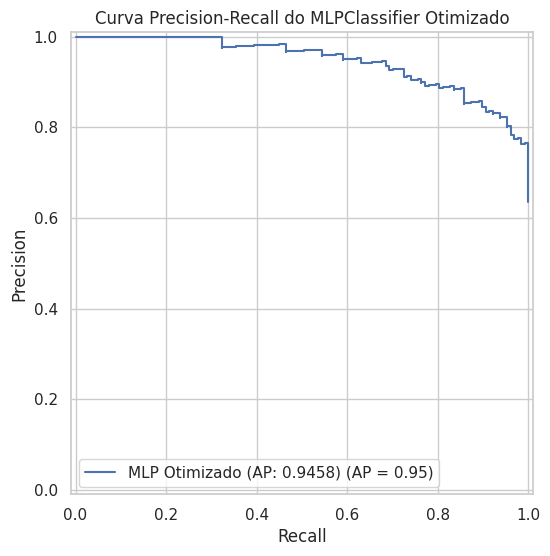

In [8]:
# Célula 10: Plotagem da Curva Precision-Recall

from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

# 1. Calcular a Área Média de Precisão (AP)
ap_optimized = average_precision_score(y_test, y_proba_optimized)

# 2. Plotar a Curva Precision-Recall
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(best_model_optimized, X_test_processed, y_test, name=f"MLP Otimizado (AP: {ap_optimized:.4f})")
plt.title('Curva Precision-Recall do MLPClassifier Otimizado')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.savefig('curva_precision_recall_mlp_otimizado.png')
plt.show()

# Heatmap de Resultados do Grid Search

Este gráfico é essencial para a documentação da otimização. Ele visualiza como o $\text{mean\_test\_score}$ (neste caso, o $\text{f1-score weighted}$) variou em função de dois dos hiperparâmetros testados. Isso ajuda a mostrar visualmente o porquê o $\text{Grid Search}$ escolheu a melhor combinação.Vamos plotar $\text{hidden\_layer\_sizes}$ contra $\text{alpha}$ para ver o impacto da arquitetura e da regularização.

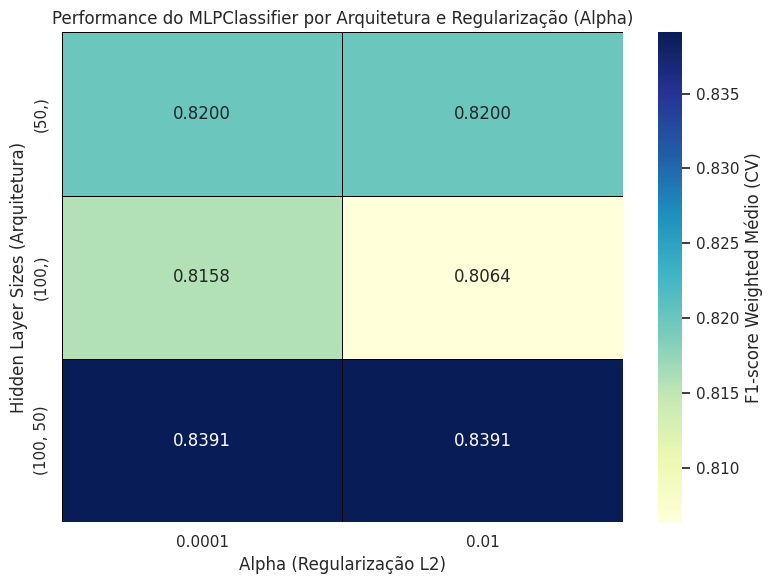

In [9]:
# 1. Converter os resultados (cv_results_) em DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# 2. Filtrar apenas o score médio de teste
# Nota: Como 'activation' e 'solver' tiveram um único valor ótimo ('relu' e 'adam'),
# vamos focar na variação de 'hidden_layer_sizes' e 'alpha'.
heatmap_data = results.pivot_table(
    values='mean_test_score',
    index='param_hidden_layer_sizes',
    columns='param_alpha'
)

# 3. Mapear os tuplos de 'hidden_layer_sizes' para strings legíveis
# (O Heatmap do Seaborn lida melhor com strings ou valores numéricos simples)
heatmap_data.index = [str(layer_size) for layer_size in heatmap_data.index]

# 4. Plotar o Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=.5, linecolor='black', cbar_kws={'label': 'F1-score Weighted Médio (CV)'})

plt.title('Performance do MLPClassifier por Arquitetura e Regularização (Alpha)')
plt.xlabel('Alpha (Regularização L2)')
plt.ylabel('Hidden Layer Sizes (Arquitetura)')
plt.tight_layout()
plt.savefig('heatmap_gridsearch_mlp.png')
plt.show()